In [28]:
import practicalSPARQL
import pandas as pd
import ast
import matplotlib.pyplot as plt
import numpy as np
import bqplot as bq
import geopandas as gpd
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.patches as mpatches
import networkx as nx
from itertools import combinations

In [29]:
df = pd.read_csv('../../DATA/02_image_clusters/full_image_data_feb_25.csv')
books = pd.read_csv('../../DATA/01_corpus_metadata/full_book_data_feb_25.csv')

In [30]:
# Assuming 'book_id' is the column to join on
df['printer'] = df['book'].map(books.set_index('book')['printers'])
df['publisher'] = df['book'].map(books.set_index('book')['publishers'])

In [31]:
# Define the target cks values
target_cks = [
'CK_Computus Ecclesiasticus Month',
'CK_Computus Ecclesiasticus Ancient Representation',
'CK_Computus Ecclesiasticus Week',
'CK_Computus Ecclesiasticus Pentacost',

]

In [32]:
#filtering the df to get the images of the target cks with all their data + printing counts
#(this is why only filter is not enough: we need all the cks that are in other rows with double images values)

# Step 1: Filter the DataFrame for rows where 'cks' is in the target_cks list
filtered_df_target_cks = df[df['cks'].isin(target_cks)]

# Step 2: Get the unique 'images' values associated with the target cks
images_with_target_cks = filtered_df_target_cks['images'].unique()

# Step 3: Filter the original DataFrame to include all rows that have these images
filtered_df = df[df['images'].isin(images_with_target_cks)]

# filtered_df

In [33]:
unique_counts = pd.concat([
    df[['images', 'cluster_name', 'cks', 'place', 'printer', 'publisher']].nunique().rename('df'),
    filtered_df[['images', 'cluster_name', 'cks', 'place', 'printer', 'publisher']].nunique().rename('filtered_df')
], axis=1)

print(unique_counts)

                 df  filtered_df
images        20540           86
cluster_name   3563            6
cks             168            4
place            42            5
printer         166           16
publisher       155           15


In [34]:
print(filtered_df['cks'].dropna().unique())


['CK_Computus Ecclesiasticus Week'
 'CK_Computus Ecclesiasticus Ancient Representation'
 'CK_Computus Ecclesiasticus Month' 'CK_Computus Ecclesiasticus Pentacost']


In [35]:
# # Extract unique values
# unique_clusters = filtered_df['cluster_name'].dropna().unique()

# # Save to CSV
# # pd.Series(unique_clusters).to_csv('/Users/nogashlomi/projects/Image_data/visual_tags/1.3.csv', index=False, header=False)

In [36]:
visual_tags = pd.read_excel('../../DATA/04_visual_tags/visual_tags/VT_1.9.xlsx')

In [37]:
# Get unique values
visual_tags_clusters = set(visual_tags['cluster_name'].unique())
filtered_df_clusters = set(filtered_df['cluster_name'].unique())

# Compare
only_in_visual_tags = visual_tags_clusters - filtered_df_clusters
only_in_filtered_df = filtered_df_clusters - visual_tags_clusters
in_both = visual_tags_clusters & filtered_df_clusters

# Print results
print("Unique cluster names only in visual_tags:")
print(sorted(only_in_visual_tags))

print("\nUnique cluster names only in filtered_df:")
print(sorted(only_in_filtered_df))

# print("\nCluster names present in both:")
# print(sorted(in_both))


Unique cluster names only in visual_tags:
['SAC_SIL_00126', 'SAC_SIL_00172', 'SAC_SIL_00181', 'SAC_SIL_00222', 'SAC_SIL_00392', 'SAC_SIL_00404', 'SAC_SIL_00473', 'SAC_SIL_00493', 'SAC_SIL_00538', 'SAC_SIL_00672', 'SAC_SIL_00789', 'SAC_SIL_00862', 'SAC_SIL_00959', 'SAC_SIL_00972', 'SAC_SIL_01057', 'SAC_SIL_01087', 'SAC_SIL_01134', 'SAC_SIL_01135', 'SAC_SIL_01136', 'SAC_SIL_01211', 'SAC_SIL_01224', 'SAC_SIL_01297', 'SAC_SIL_01332', 'SAC_SIL_01363', 'SAC_SIL_01415', 'SAC_SIL_01493', 'SAC_SIL_01510', 'SAC_SIL_01536', 'SAC_SIL_01696', 'SAC_SIL_01790', 'SAC_SIL_01809', 'SAC_SIL_01829', 'SAC_SIL_01840', 'SAC_SIL_01860', 'SAC_SIL_02020', 'SAC_SIL_02043', 'SAC_SIL_02136', 'SAC_SIL_02191', 'SAC_SIL_02241', 'SAC_SIL_02263', 'SAC_SIL_02265', 'SAC_SIL_02288', 'SAC_SIL_02480', 'SAC_SIL_02519', 'SAC_SIL_02536', 'SAC_SIL_02691', 'SAC_SIL_02714', 'SAC_SIL_02845', 'SAC_SIL_02910', 'SAC_SIL_03172', 'SAC_SIL_03400', 'SAC_SIL_03686', 'SAC_SIL_03768', 'SAC_SIL_03811', 'SAC_SIL_03814']

Unique cluster names 

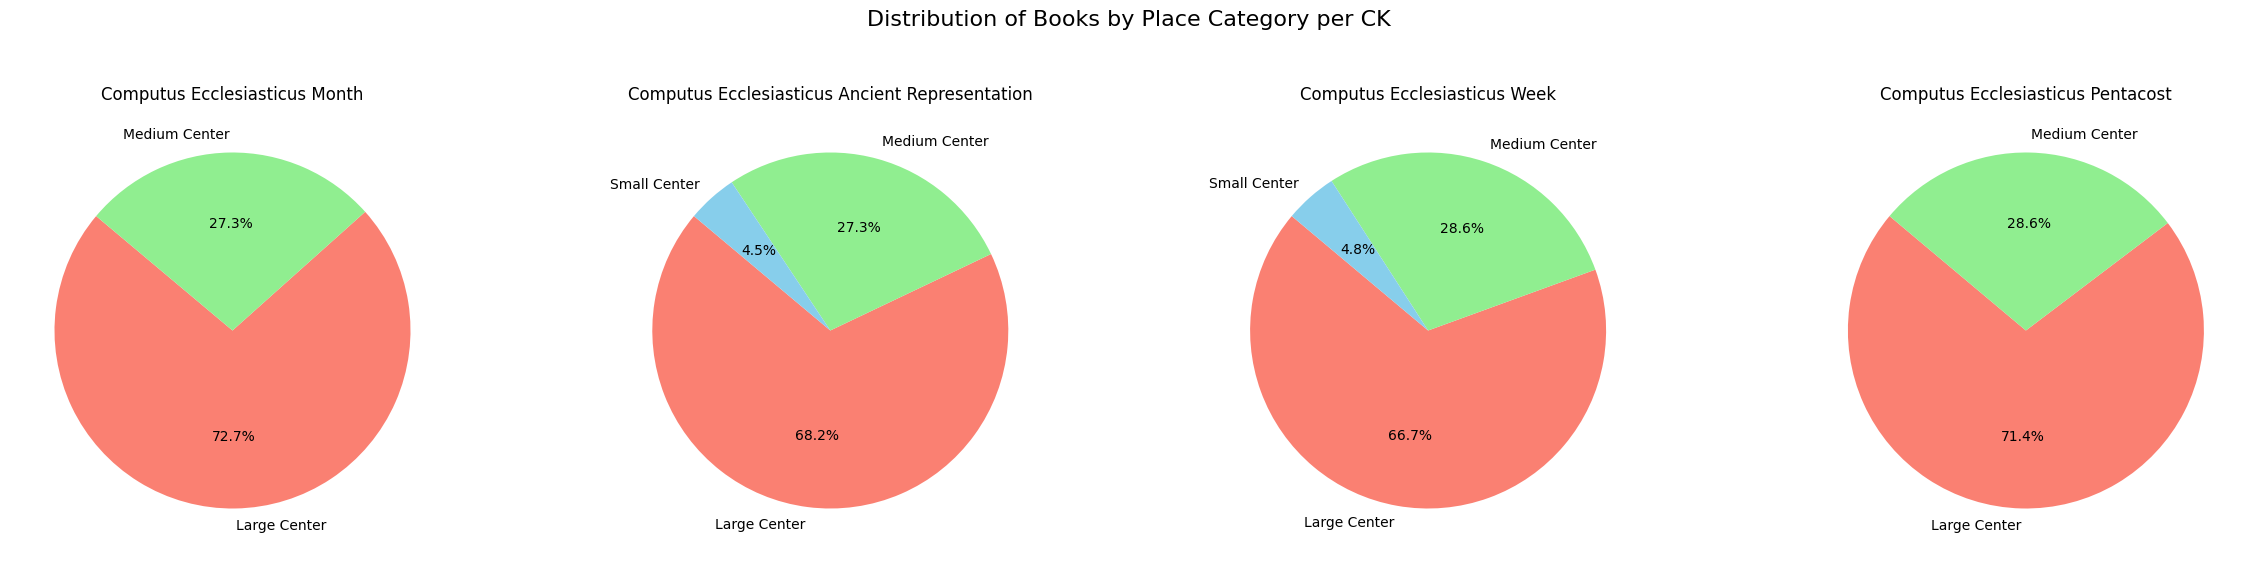

In [38]:
# === Assume filtered_df already filtered to target_cks ===

target_cks = [
'CK_Computus Ecclesiasticus Month',
'CK_Computus Ecclesiasticus Ancient Representation',
'CK_Computus Ecclesiasticus Week',
'CK_Computus Ecclesiasticus Pentacost',

]


# Drop duplicates per (CK, book) — this is the key line
unique_ck_books = filtered_df.drop_duplicates(subset=['cks', 'book'])

# Prepare consistent color map
place_categories = unique_ck_books['place_category'].dropna().unique().tolist()
color_palette = ['skyblue', 'salmon', 'lightgreen', 'khaki', 'plum', 'orange', 'lightcoral', 'lightsteelblue']
category_color_map = {
    cat: color_palette[i % len(color_palette)] for i, cat in enumerate(place_categories)
}

# Setup plots
num_cks = len(target_cks)
fig, axes = plt.subplots(1, num_cks, figsize=(6 * num_cks, 6))
if num_cks == 1:
    axes = [axes]

# Group by CK after deduplication
grouped = unique_ck_books.groupby('cks')

# Loop through CKs and plot pies
for ax, ck in zip(axes, target_cks):
    if ck in grouped.groups:
        ck_df = grouped.get_group(ck)
        counts = ck_df.groupby('place_category')['book'].nunique().sort_values(ascending=False)
        colors = [category_color_map.get(cat, 'gray') for cat in counts.index]

        ax.pie(
            counts,
            labels=counts.index,
            autopct='%1.1f%%',
            colors=colors,
            startangle=140
        )
        ax.set_title(ck.replace('CK_', '').replace('_', ' '), fontsize=12)
    else:
        ax.set_title(f'{ck}: No Data')
        ax.axis('off')

# Final layout
plt.suptitle('Distribution of Books by Place Category per CK', fontsize=16)
plt.tight_layout(rect=[0, 0.05, 1, 0.9])
# plt.savefig('/Users/nogashlomi/projects/nog_thesis/figures/plots/source_analysis/1.9_place_cat_pie.png', dpi=300)

plt.show()

Number of Unique Books per CK Group, All Books, and Filtered Books:
               CK_Computus Ecclesiasticus Month  \
year_interval                                     
1470-1489                                   0.0   
1490-1509                                   1.0   
1510-1529                                   0.0   
1530-1549                                   5.0   
1550-1569                                   9.0   
1570-1589                                   5.0   
1590-1609                                   1.0   
1610-1629                                   1.0   
1630-1650                                   0.0   

               CK_Computus Ecclesiasticus Ancient Representation  \
year_interval                                                      
1470-1489                                                    0.0   
1490-1509                                                    0.0   
1510-1529                                                    0.0   
1530-1549                     

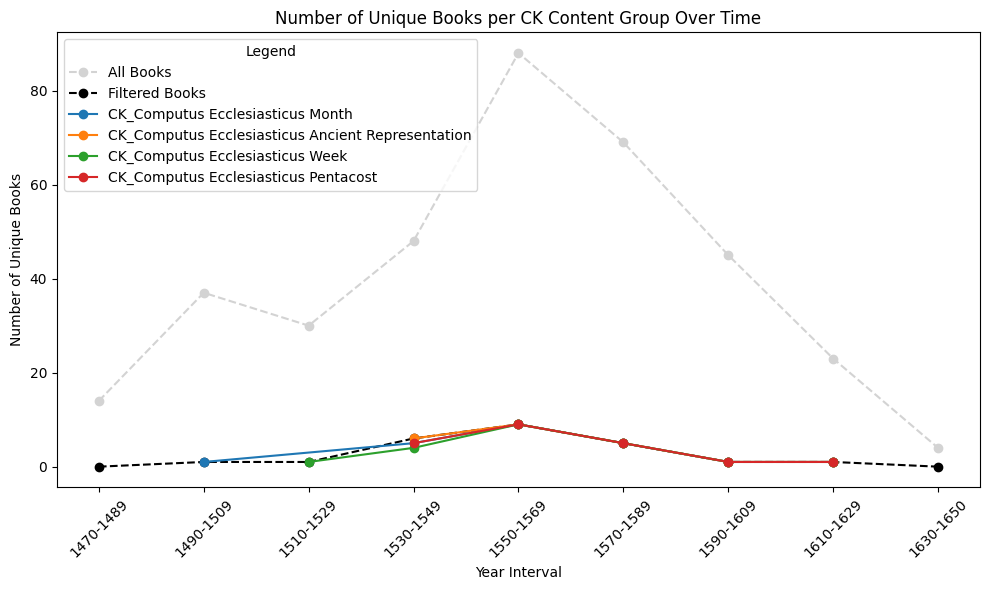

In [39]:
import pandas as pd
import matplotlib.pyplot as plt

# Define target CK tags
target_cks = [
'CK_Computus Ecclesiasticus Month',
'CK_Computus Ecclesiasticus Ancient Representation',
'CK_Computus Ecclesiasticus Week',
'CK_Computus Ecclesiasticus Pentacost',

]

# ✅ 1. Total books per year_interval (from full books df)
all_books_count = books.groupby('year_interval', observed=False)['book'].nunique()

# ✅ 2. Total books per year_interval (from filtered_df)
filtered_books_count = filtered_df.groupby('year_interval', observed=False)['book'].nunique()

# ✅ Use the full timeline from all_books_count
intervals = all_books_count.index.astype(str)

# ✅ 3. Book counts per CK from filtered_df
book_counts = {
    keyword: (
        filtered_df[filtered_df['cks'] == keyword]
        .groupby('year_interval', observed=False)['book']
        .nunique()
        .to_dict()
    )
    for keyword in target_cks
}

# ✅ 4. Create unified DataFrame
book_counts_df = pd.DataFrame(book_counts).reindex(all_books_count.index).fillna(0)
book_counts_df['All Books'] = all_books_count
book_counts_df['Filtered Books'] = filtered_books_count.reindex(all_books_count.index).fillna(0)

# ✅ 5. Print the summary table
print("Number of Unique Books per CK Group, All Books, and Filtered Books:")
print(book_counts_df)

# ✅ 6. Plotting
plt.figure(figsize=(10, 6))

# Plot total number of books (full dataset)
plt.plot(intervals, book_counts_df['All Books'].values, label='All Books', marker='o', color='lightgrey', linestyle='--')

# Plot number of filtered books
plt.plot(intervals, book_counts_df['Filtered Books'].values, label='Filtered Books', marker='o', color='black', linestyle='--')

# Plot each CK content group (only where values are non-zero)
for keyword in target_cks:
    values = book_counts_df[keyword].values
    non_zero_intervals = [intervals[i] for i, val in enumerate(values) if val > 0]
    non_zero_values = [val for val in values if val > 0]

    if non_zero_values:
        plt.plot(non_zero_intervals, non_zero_values, marker='o', label=keyword)

# ✅ 7. Final touches
plt.title('Number of Unique Books per CK Content Group Over Time')
plt.xlabel('Year Interval')
plt.ylabel('Number of Unique Books')
plt.xticks(rotation=45)
plt.legend(title='Legend')
plt.tight_layout()

# ✅ 8. Save the figure
# plt.savefig('/Users/nogashlomi/projects/nog_thesis/figures/plots/source_analysis/1.9_num_books_cks.png', dpi=300)

# ✅ 9. Show the plot
plt.show()


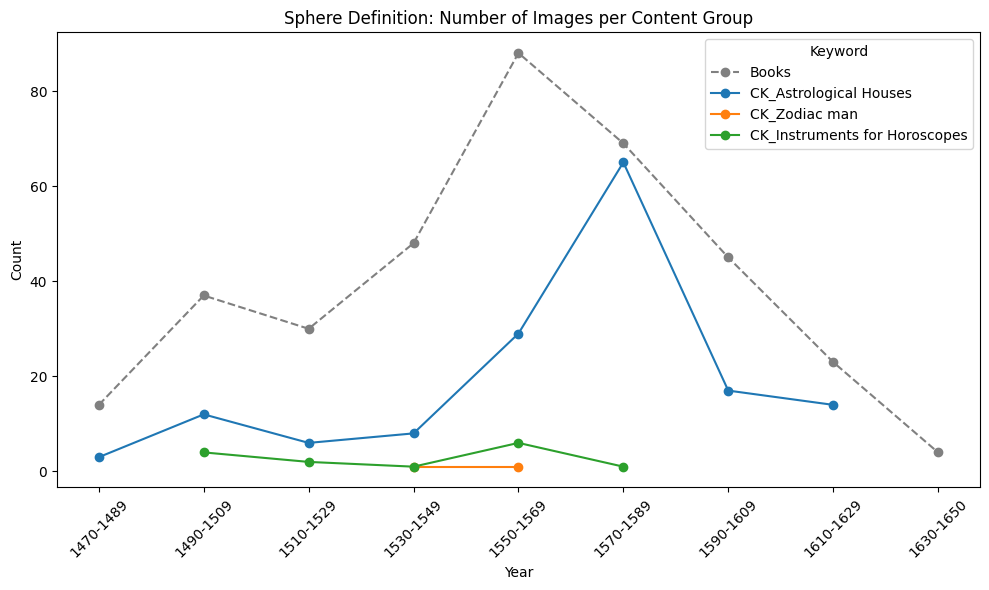

In [31]:
#plot number of images over time from the target cks

# Get unique books per year_interval
unique_books_count = books.groupby('year_interval', observed=False)['book'].nunique()

# Define the master timeline from book data
intervals = unique_books_count.index.astype(str)

# Dictionary: {keyword: {interval: unique_image_count}}
counts = {
    keyword: (
        filtered_df[filtered_df['cks'] == keyword]
        .groupby('year_interval', observed=False)['images']
        .nunique()
        .to_dict()
    )
    for keyword in target_cks
}

# # Create a DataFrame for tabular display (fills in 0 for missing intervals)
# counts_table = pd.DataFrame(counts, index=unique_books_count.index).fillna(0).astype(int)
# print("\n=== Unique Image Counts per CK per Interval ===")
# print(counts_table)

# Start plotting
plt.figure(figsize=(10, 6))

# Plot books
plt.plot(intervals, unique_books_count.values, label='Books', marker='o', color='grey', linestyle='--')

# Plot each keyword (excluding zero values from the line)
for keyword in target_cks:
    data = counts.get(keyword, {})
    keyword_values = [data.get(interval, 0) for interval in unique_books_count.index]
    non_zero_intervals = [intervals[i] for i, val in enumerate(keyword_values) if val > 0]
    non_zero_values = [val for val in keyword_values if val > 0]
    
    if non_zero_values:
        plt.plot(non_zero_intervals, non_zero_values, marker='o', label=keyword)

# Final touches
plt.title('Sphere Definition: Number of Images per Content Group')
plt.xlabel('Year')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.legend(title='Keyword')
plt.tight_layout()

# Save the plot
# plt.savefig('/Users/nogashlomi/projects/nog_thesis/figures/plots/source_analysis/1.9_images_cks.png', dpi=300)
plt.show()


In [32]:
#merge visual tags with filtered_df on cluster_name
visual_df = pd.merge(filtered_df, visual_tags, on='cluster_name')
# visual_df

In [33]:
print(visual_df.columns)


Index(['images', 'cluster_name', 'cks', 'book', 'bid', 'part_or_adaption',
       'part_or_adaption_label', 'type_label', 'custom_identifier', 'place',
       'year', 'flag', 'year_interval', 'place_category', 'latitude',
       'longitude', 'printer', 'publisher', '3D', 'human figures', 'simple',
       'color', 'diagram', 'decoration', 'material globus',
       'multiple perspectives'],
      dtype='object')


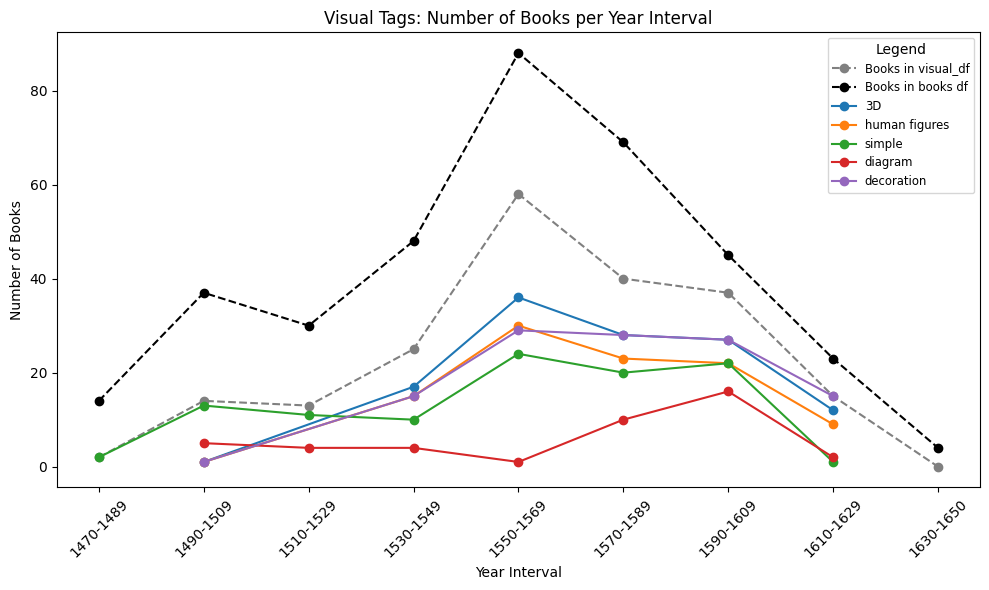

In [60]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

# Define visual tag columns
defined_columns = [
    '3D', 
    'human figures', 
    'simple',
    # 'color', 
    'diagram', 
    'decoration', 
    # 'material globus',
    # 'multiple perspectives'
]

# Get the union of intervals from both dataframes to ensure completeness
intervals = sorted(set(books['year_interval'].dropna().unique()) | set(visual_df['year_interval'].dropna().unique()))
x_range = range(len(intervals))  # Used for consistent indexing on x-axis

# 1. Total unique books per interval in visual_df
unique_books_visual = (
    visual_df.groupby('year_interval', observed=False)['book']
    .nunique()
    .reindex(intervals, fill_value=0)
)

# 2. Total unique books per interval in books df
unique_books_from_books_df = (
    books.groupby('year_interval', observed=False)['book']
    .nunique()
    .reindex(intervals, fill_value=0)
)

# Plot total lines
plt.plot(x_range, unique_books_visual.values, label='Books in visual_df', marker='o', color='grey', linestyle='--')
plt.plot(x_range, unique_books_from_books_df.values, label='Books in books df', marker='o', color='black', linestyle='--')

# 3. Plot each visual tag with zero-excluding logic
for col in defined_columns:
    books_with_tag = (
        visual_df[visual_df[col] == 'yes']
        .groupby('year_interval', observed=False)['book']
        .nunique()
        .reindex(intervals, fill_value=0)
    )

    # Filter out intervals with zero values
    non_zero_points = [(i, val) for i, val in enumerate(books_with_tag.values) if val > 0]
    if non_zero_points:
        idxs, vals = zip(*non_zero_points)
        plt.plot(idxs, vals, marker='o', label=col)

# Final formatting
plt.title('Visual Tags: Number of Books per Year Interval')
plt.xlabel('Year Interval')
plt.ylabel('Number of Books')
plt.xticks(ticks=x_range, labels=intervals, rotation=45)
plt.legend(title='Legend', fontsize='small', title_fontsize='medium')
plt.tight_layout()

# Save and show
# plt.savefig('/Users/nogashlomi/projects/nog_thesis/figures/plots/source_analysis/1.9_visual.png', dpi=300)
plt.show()


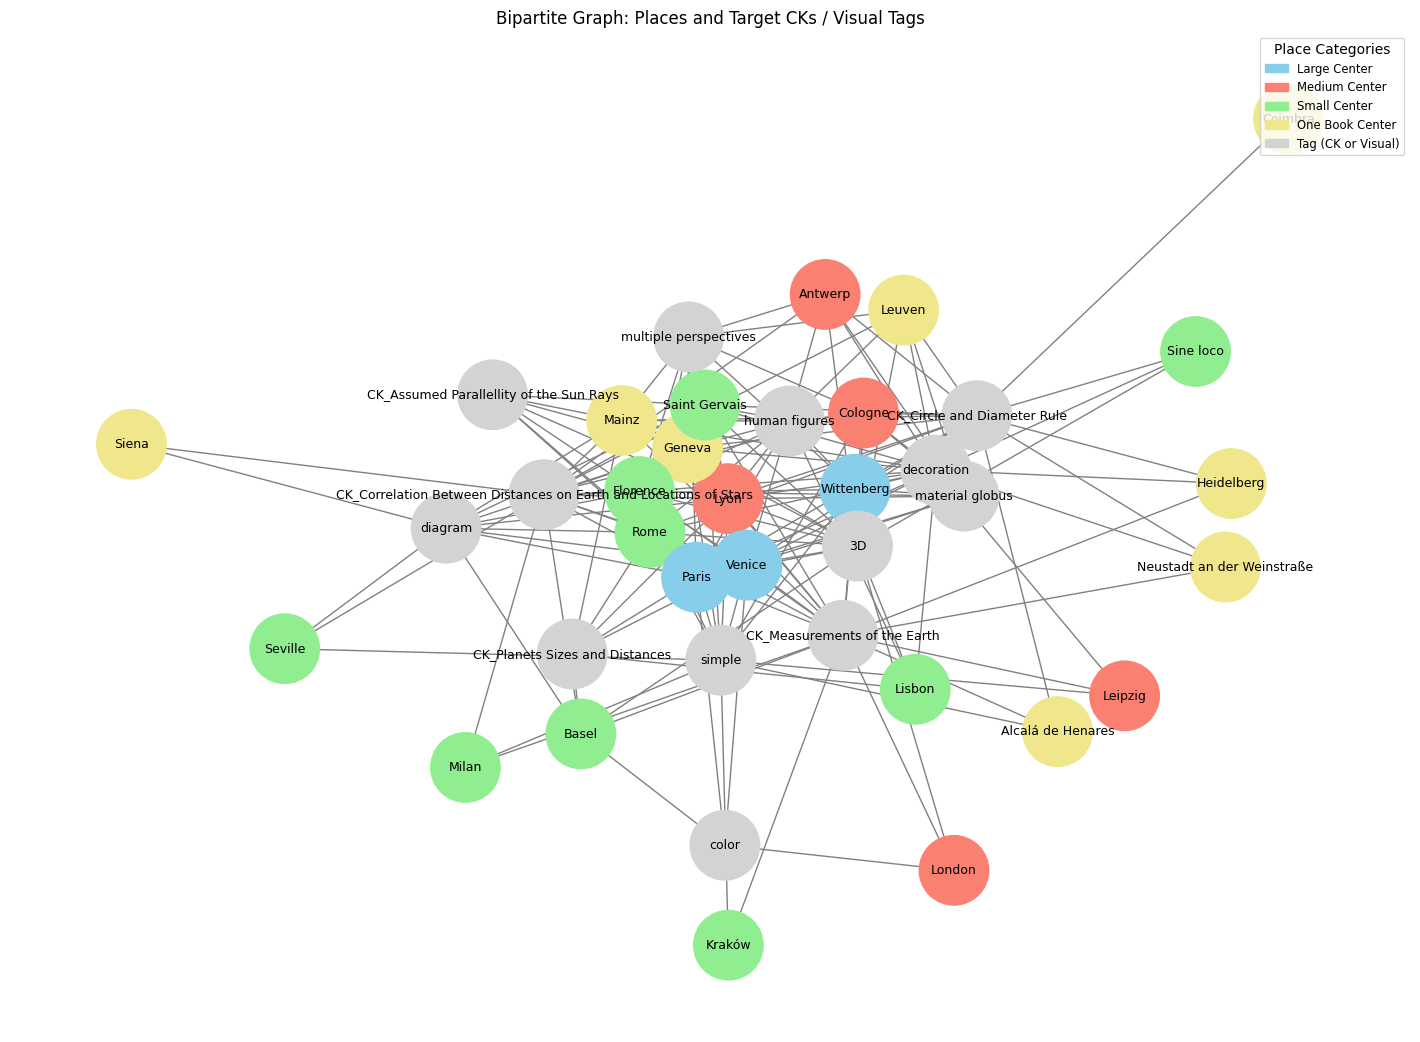

In [61]:

# === Assumes this is already defined earlier ===
# target_cks = ['CK_Sphericity of the Water Element',
#               'CK_Relation Between the Spheres of Water and Earth'
#               ]

# === Step 1: Visual tags ===
defined_columns = [
    '3D', 
    'human figures', 
    'simple',
    # 'color', 
    'diagram', 
    'decoration', 
    'material globus',
    # 'multiple perspectives'
        ]

# === Step 2: Build edge list ===
edges = []
places = visual_df['place'].dropna().unique().tolist()

for place in places:
    place_data = visual_df[visual_df['place'] == place]

    # Add CKs only if in target_cks
    for cks in target_cks:
        if (place_data['cks'] == cks).any():
            edges.append((place, cks))

    # Add visual tag edges
    for tag in visual_tags:
        if (place_data[tag] == 'yes').any():
            edges.append((place, tag))

# Optional: inspect edge structure
# edges_df = pd.DataFrame(edges, columns=['place', 'tag'])
# print(edges_df)

# === Step 3: Unique node sets ===
places = list(set(edge[0] for edge in edges))
tags = list(set(edge[1] for edge in edges))

# === Step 4: Color by place category ===
ordered_categories = ['Large Center', 'Medium Center', 'Small Center', 'One Book Center']
existing_categories = visual_df['place_category'].dropna().unique()
ordered_present_categories = [cat for cat in ordered_categories if cat in existing_categories]

color_palette = ['skyblue', 'salmon', 'lightgreen', 'khaki']
category_color_map = {
    cat: color for cat, color in zip(ordered_present_categories, color_palette)
}

place_color_map = {}
for place in places:
    cat_series = visual_df[visual_df['place'] == place]['place_category'].dropna()
    category = cat_series.iloc[0] if not cat_series.empty else 'unknown'
    place_color_map[place] = category_color_map.get(category, 'gray')

# === Step 5: Build the graph ===
G = nx.Graph()
G.add_nodes_from(places, bipartite=0)
G.add_nodes_from(tags, bipartite=1)
G.add_edges_from(edges)

# === Step 6: Assign node colors ===
node_colors = [
    place_color_map[node] if node in places else 'lightgray'
    for node in G.nodes()
]

# === Step 7: Draw ===
plt.figure(figsize=(14, 10))
pos = nx.spring_layout(G, seed=42)
nx.draw(
    G,
    pos,
    with_labels=True,
    node_color=node_colors,
    edge_color='gray',
    node_size=2500,
    font_size=9
)

# === Step 8: Legend ===
legend_handles = [
    mpatches.Patch(color=category_color_map[cat], label=cat)
    for cat in ordered_present_categories
]
legend_handles.append(mpatches.Patch(color='lightgray', label='Tag (CK or Visual)'))

plt.legend(
    handles=legend_handles,
    title='Place Categories',
    loc='upper right',
    fontsize='small',
    title_fontsize='medium'
)
plt.title("Bipartite Graph: Places and Target CKs / Visual Tags")

# === Step 9: Save or show ===
# plt.savefig('/Users/nogashlomi/projects/nog_thesis/figures/plots/source_analysis/1.9_network.png', dpi=300)
plt.show()


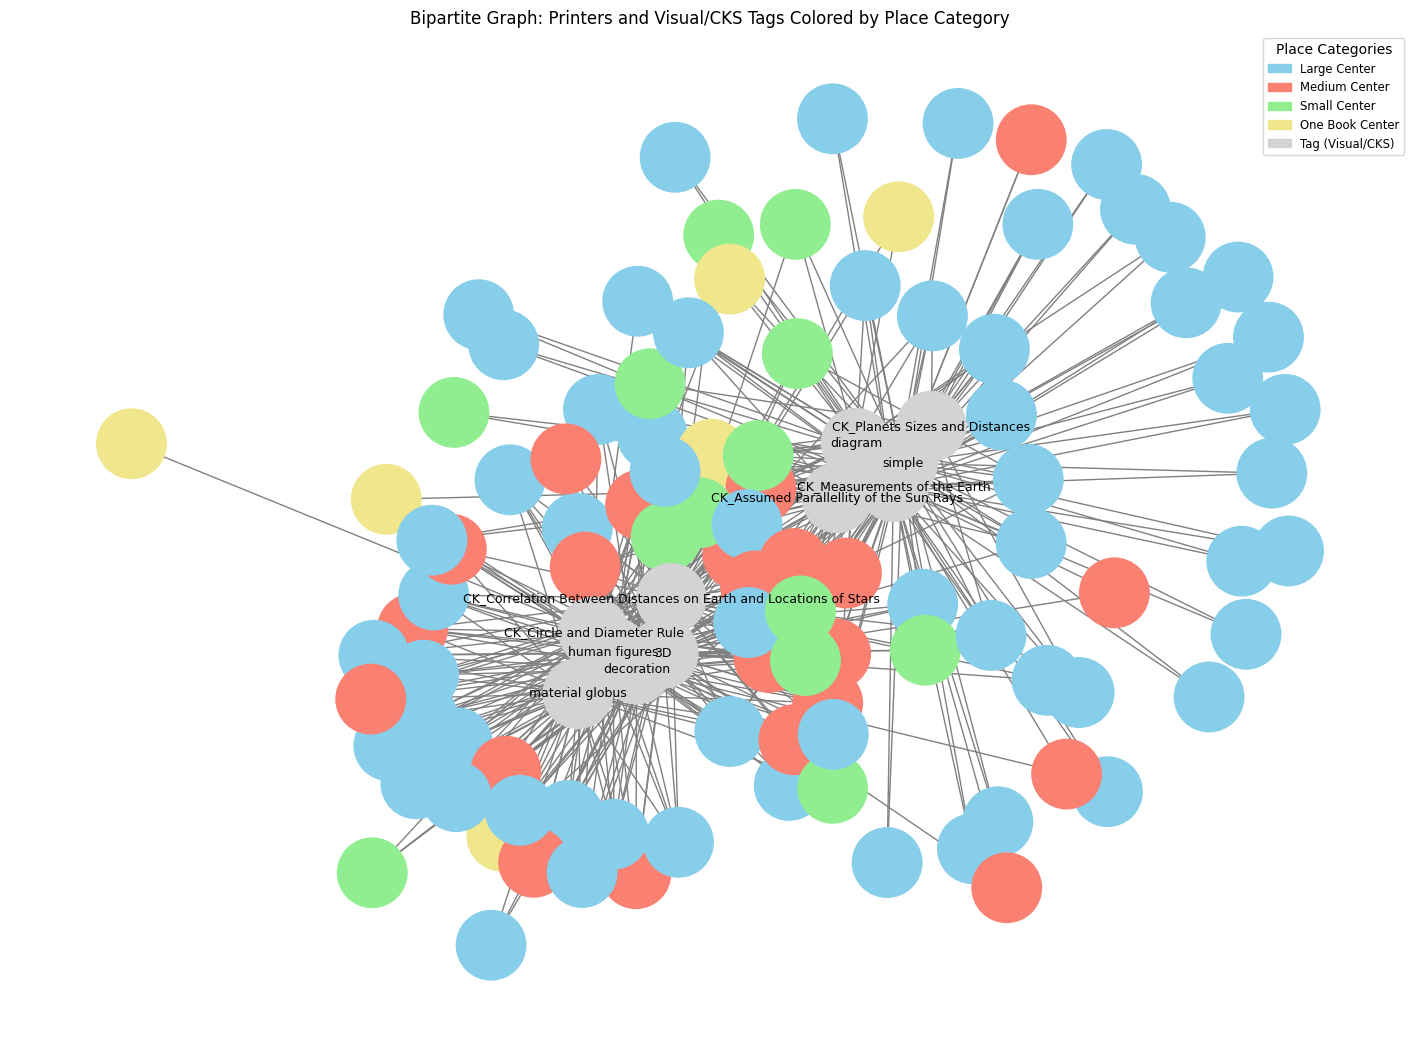

In [62]:
# === Step 1: Define CKs and visual tags ===
# target_cks = ['function', 'craft', 'symbolism', 'geometry']  # Adjust as needed
visual_tag_cols = [
    '3D', 
    'human figures', 
    'simple',
    # 'color', 
    'diagram', 
    'decoration', 
    'material globus',
    # 'multiple perspectives'
    ]

all_tags = target_cks + visual_tag_cols

# === Step 2: Build the edge list ===
edges = []
printers = visual_df['printer'].dropna().unique().tolist()

for printer in printers:
    printer_data = visual_df[visual_df['printer'] == printer]

    # CK edges
    for cks in target_cks:
        if (printer_data['cks'] == cks).any():
            edges.append((printer, cks))

    # Visual tag edges
    for tag in visual_tag_cols:
        if (printer_data[tag] == 'yes').any():
            edges.append((printer, tag))

# === Step 3: Extract node sets ===
all_printers = list(set(edge[0] for edge in edges))
all_tag_nodes = list(set(edge[1] for edge in edges))

# === Step 4: Assign colors to printers based on place category ===
ordered_categories = ['Large Center', 'Medium Center', 'Small Center', 'One Book Center']
category_color_map = {
    'Large Center': 'skyblue',
    'Medium Center': 'salmon',
    'Small Center': 'lightgreen',
    'One Book Center': 'khaki'
}

printer_color_map = {}
for printer in all_printers:
    cat_series = visual_df[visual_df['printer'] == printer]['place_category'].dropna()
    category = cat_series.iloc[0] if not cat_series.empty else None
    printer_color_map[printer] = category_color_map.get(category, 'gray')

# === Step 5: Build and draw graph ===
G = nx.Graph()
G.add_nodes_from(all_printers, bipartite=0)
G.add_nodes_from(all_tag_nodes, bipartite=1)
G.add_edges_from(edges)

# Node colors
node_colors = [
    printer_color_map[node] if node in all_printers else 'lightgray'
    for node in G.nodes()
]

# Labels: only for tags (not printers)
labels = {node: node for node in all_tag_nodes}

# Draw
plt.figure(figsize=(14, 10))
pos = nx.spring_layout(G, seed=42, k=0.5)
nx.draw(
    G, pos,
    labels=labels,
    node_color=node_colors,
    edge_color='gray',
    node_size=2500,
    font_size=9
)

# Legend
legend_handles = [mpatches.Patch(color=category_color_map[cat], label=cat) for cat in ordered_categories]
legend_handles.append(mpatches.Patch(color='lightgray', label='Tag (Visual/CKS)'))

plt.legend(handles=legend_handles, title='Place Categories', loc='upper right', fontsize='small', title_fontsize='medium')
plt.title("Bipartite Graph: Printers and Visual/CKS Tags Colored by Place Category")

# Export or show
# plt.savefig('/Users/nogashlomi/projects/nog_thesis/figures/plots/source_analysis/1.9_printer_network.png', dpi=300, facecolor='white')
plt.show()


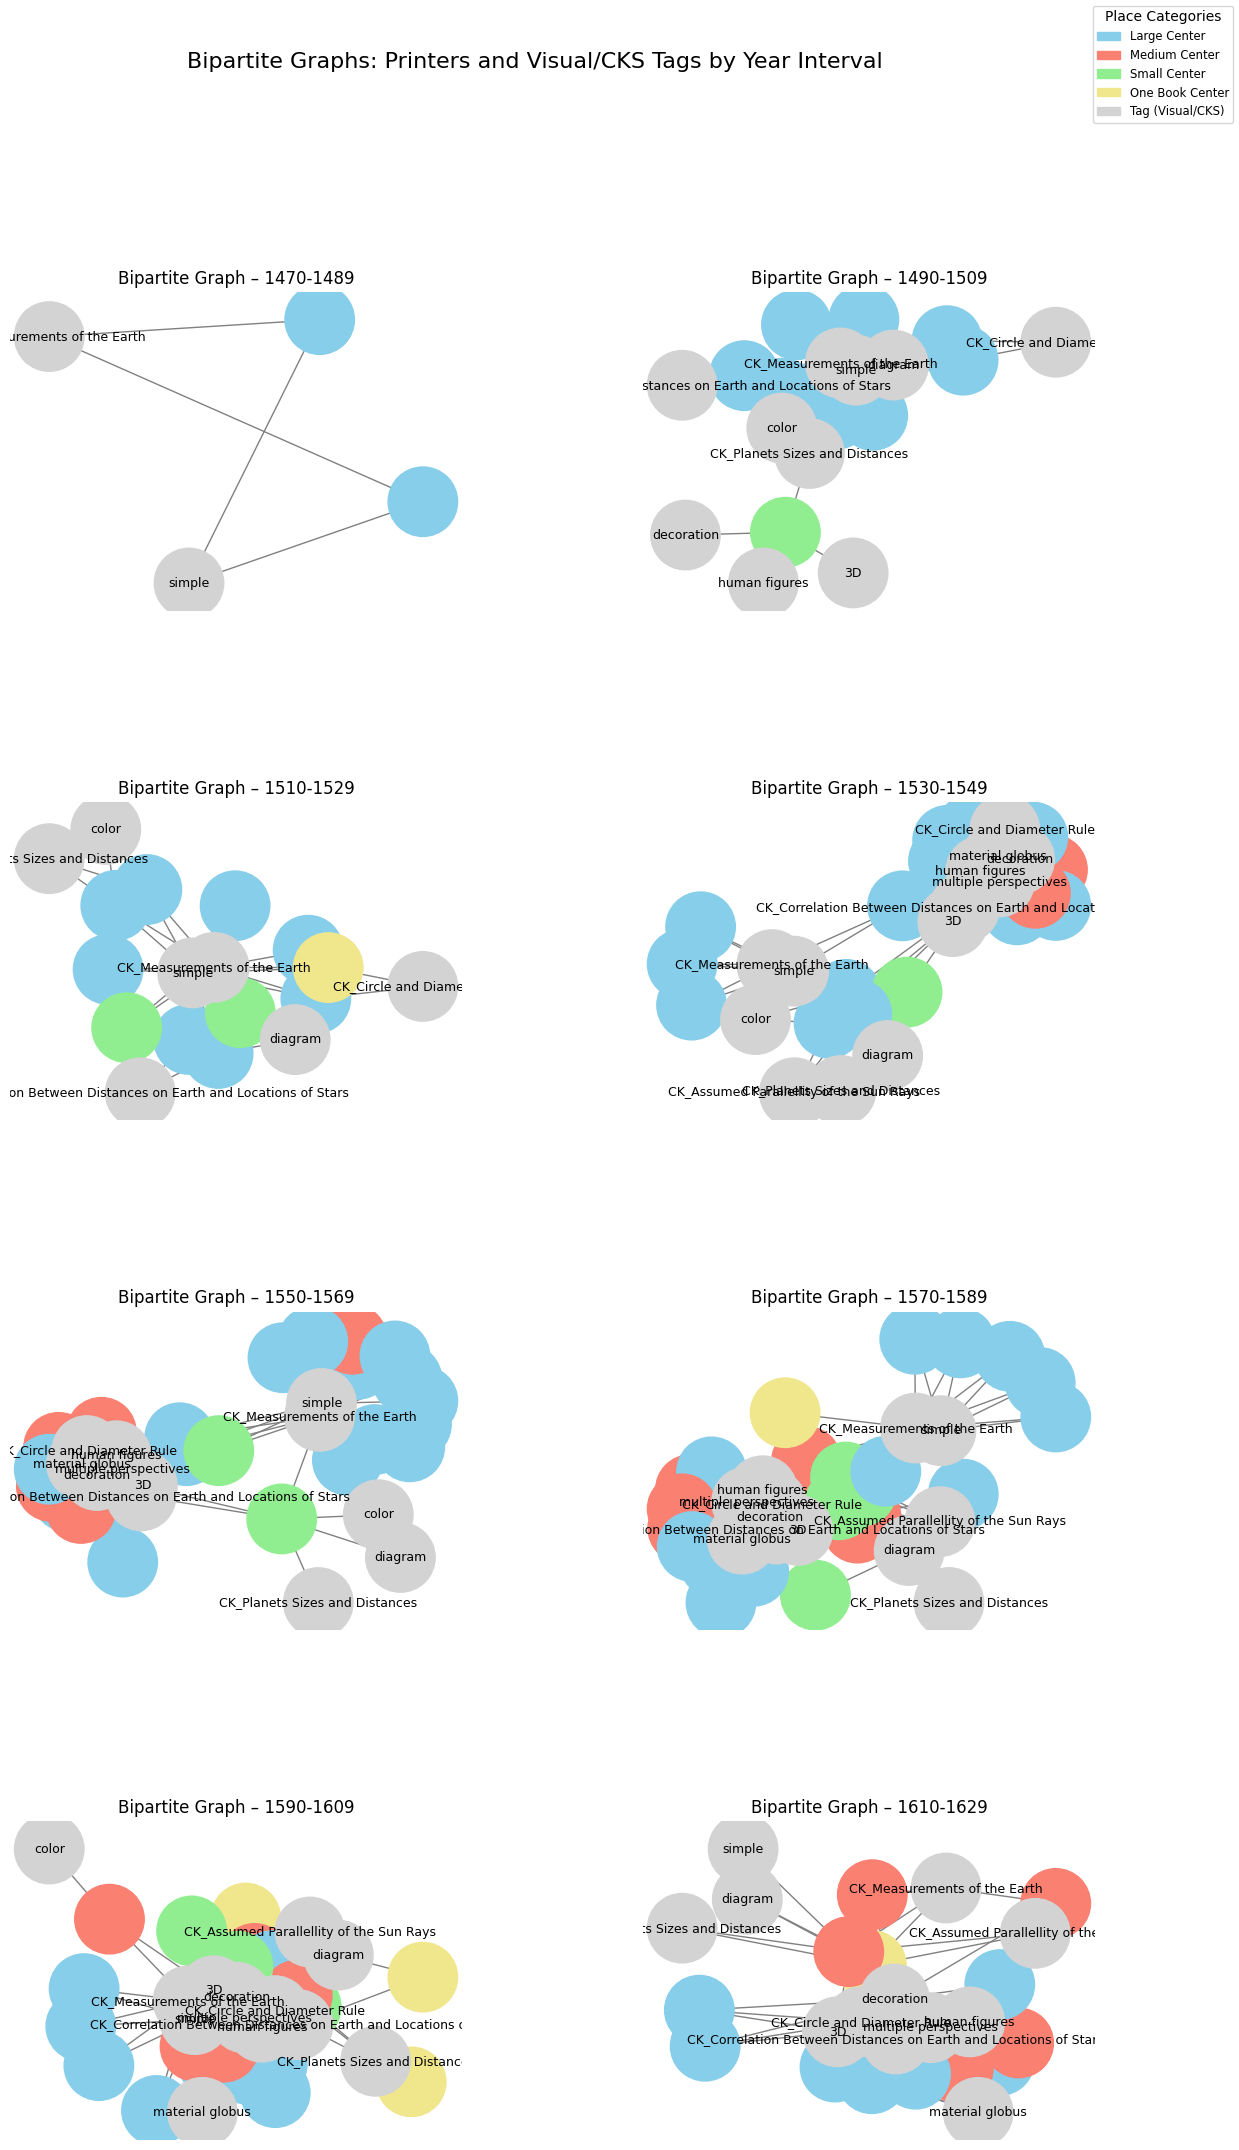

In [63]:
# === Assumes this is already defined earlier ===
# target_cks = ['CK_Sphericity of the Water Element',
#               'CK_Relation Water Earth Spheres'
#               ]

# === Step 1: Visual tags ===
visual_tag_cols = [
    '3D', 
    'human figures', 
    'simple',
    'color', 
    'diagram', 
    'decoration', 
    'material globus',
    'multiple perspectives'
    ]

all_tags = target_cks + visual_tag_cols

ordered_categories = ['Large Center', 'Medium Center', 'Small Center', 'One Book Center']
category_color_map = {
    'Large Center': 'skyblue',
    'Medium Center': 'salmon',
    'Small Center': 'lightgreen',
    'One Book Center': 'khaki'
}

# === GET UNIQUE YEAR INTERVALS ===
intervals = sorted(visual_df['year_interval'].dropna().unique())

# === CREATE PLOTS PER INTERVAL ===
n_cols = 2
n_rows = (len(intervals) + 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 6 * n_rows))
axes = axes.flatten()
plt.subplots_adjust(wspace=0.4, hspace=0.6)

for i, interval in enumerate(intervals):
    ax = axes[i]
    df_interval = visual_df[visual_df['year_interval'] == interval].copy()
    printers = df_interval['printer'].dropna().unique().tolist()
    edges = []

    for printer in printers:
        printer_data = df_interval[df_interval['printer'] == printer]

        # CKS edges
        for cks in target_cks:
            if (printer_data['cks'] == cks).any():
                edges.append((printer, cks))

        # Visual tag edges
        for tag in visual_tag_cols:
            if tag in printer_data.columns and (printer_data[tag] == 'yes').any():
                edges.append((printer, tag))

    # Unique nodes
    all_printers = list(set(edge[0] for edge in edges))
    all_tag_nodes = list(set(edge[1] for edge in edges))

    # Color mapping
    printer_color_map = {
        printer: category_color_map.get(
            visual_df[visual_df['printer'] == printer]['place_category'].dropna().iloc[0],
            'gray'
        )
        for printer in all_printers
    }

    # Graph
    G = nx.Graph()
    G.add_nodes_from(all_printers, bipartite=0)
    G.add_nodes_from(all_tag_nodes, bipartite=1)
    G.add_edges_from(edges)

    # Colors and labels
    node_colors = [
        printer_color_map.get(node, 'gray') if node in all_printers else 'lightgray'
        for node in G.nodes()
    ]
    labels = {node: node for node in all_tag_nodes}

    # Draw
    pos = nx.spring_layout(G, seed=42, k=0.5)
    nx.draw(
        G, pos,
        labels=labels,
        node_color=node_colors,
        edge_color='gray',
        node_size=2500,
        font_size=9,
        ax=ax
    )

    ax.set_title(f"Bipartite Graph – {interval}", fontsize=12)
    ax.axis('off')

# Remove empty subplots if any
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

# === LEGEND ===
legend_handles = [mpatches.Patch(color=category_color_map[cat], label=cat) for cat in ordered_categories]
legend_handles.append(mpatches.Patch(color='lightgray', label='Tag (Visual/CKS)'))

fig.legend(
    handles=legend_handles,
    title='Place Categories',
    loc='upper right',
    fontsize='small',
    title_fontsize='medium'
)

plt.suptitle("Bipartite Graphs: Printers and Visual/CKS Tags by Year Interval", fontsize=16)

# Optionally save
# plt.savefig('/Users/nogashlomi/projects/nog_thesis/figures/plots/source_analysis/graph_by_year_interval.png', dpi=300)


plt.show()


/var/folders/6r/8tpplrhn0rlglqf49qymjfmc0000gn/T/ipykernel_49326/944037490.py:135: UserWarning: Tight layout not applied. tight_layout cannot make Axes width small enough to accommodate all Axes decorations
  plt.tight_layout(rect=[0, 0.07, 1, 0.95])  # leave space for legend and title


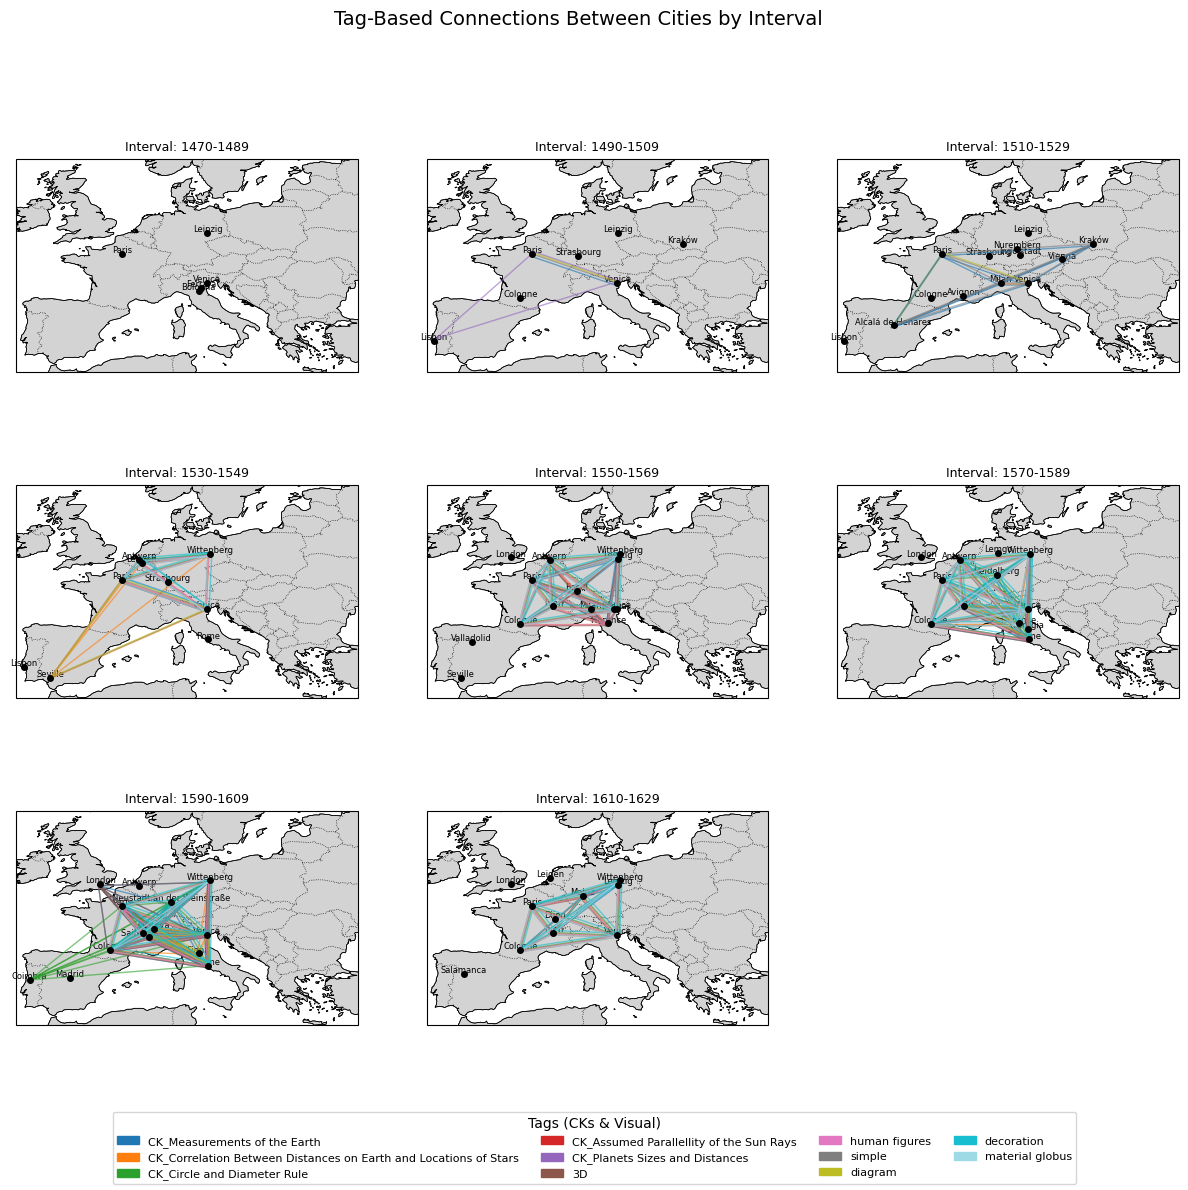

In [66]:
#geotemporal with all cities of the corpus 
#per interval and colored connections by cks and visual tags


# === Settings ===
target_visual_tags = [
    '3D', 
    'human figures', 
    'simple',
    # 'color', 
    'diagram', 
    'decoration', 
    'material globus',
    # 'multiple perspectives'
]

# # Replace with your actual CK list
# target_cks = [
#     'CK_Crossing Point of Eclipses',
#     'CK_Negligible Size',
#     'CK_Visibility of Half the Heavens',
#     # etc.
# ]

# Color map
all_tags = target_cks + target_visual_tags
colors = plt.cm.tab20(np.linspace(0, 1, len(all_tags)))
tag_color_map = dict(zip(all_tags, colors))

# Bounding box
min_lon, max_lon = -10, 30
min_lat, max_lat = 35, 60

# Sorted time intervals
sorted_intervals = sorted(visual_df['year_interval'].dropna().unique())

# === Function to plot one interval ===
def plot_tag_lines_on_ax(ax, interval):
    df_interval = visual_df[visual_df['year_interval'] == interval].copy()

    gdf = gpd.GeoDataFrame(
        df_interval,
        geometry=gpd.points_from_xy(df_interval['longitude'], df_interval['latitude']),
        crs="EPSG:4326"
    ).dropna(subset=['longitude', 'latitude'])

    # All cities from full df
    all_cities_df = df[df['year_interval'] == interval].copy()
    all_cities_df = all_cities_df.dropna(subset=['longitude', 'latitude'])
    all_cities_df = all_cities_df.drop_duplicates(subset=['place'])

    ax.set_extent([min_lon, max_lon, min_lat, max_lat], crs=ccrs.PlateCarree())
    ax.add_feature(cfeature.BORDERS, linestyle=':', linewidth=0.5)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
    ax.add_feature(cfeature.LAND, edgecolor='black', facecolor='lightgray', linewidth=0.5)

    jitter_amount = 0.12

    for tag_index, tag in enumerate(all_tags):
        if tag in target_cks:
            tagged_cities = gdf[gdf['cks'] == tag]
        else:
            tagged_cities = gdf[gdf[tag] == 'yes']

        tagged_coords = tagged_cities[['place', 'longitude', 'latitude']].drop_duplicates()
        jitter_offset = (tag_index % 5 - 2) * jitter_amount

        for (i1, row1), (i2, row2) in combinations(tagged_coords.iterrows(), 2):
            if (row1['longitude'] == row2['longitude']) and (row1['latitude'] == row2['latitude']):
                continue

            ax.plot(
                [row1['longitude'] + jitter_offset, row2['longitude'] + jitter_offset],
                [row1['latitude'] + jitter_offset, row2['latitude'] + jitter_offset],
                color=tag_color_map[tag],
                linewidth=1,
                alpha=0.6,
                transform=ccrs.PlateCarree(),
                zorder=4
            )

    # Plot all city dots
    for _, row in all_cities_df.iterrows():
        ax.plot(
            row['longitude'], row['latitude'],
            marker='o', color='black', markersize=4,
            transform=ccrs.PlateCarree(),
            zorder=5
        )
        ax.text(
            row['longitude'], row['latitude'] + 0.15,
            row['place'], fontsize=6, ha='center',
            transform=ccrs.PlateCarree()
        )

    ax.set_title(f"Interval: {interval}", fontsize=9)


# === Plotting pages in 3x3 grid ===
per_page = 9
num_pages = int(np.ceil(len(sorted_intervals) / per_page))

for page in range(num_pages):
    start = page * per_page
    end = min((page + 1) * per_page, len(sorted_intervals))
    intervals_subset = sorted_intervals[start:end]

    fig, axs = plt.subplots(
        3, 3,
        figsize=(15, 12),  # enough space, but tight
        subplot_kw={'projection': ccrs.PlateCarree()}
    )
    axs = axs.flatten()

    for i, interval in enumerate(intervals_subset):
        plot_tag_lines_on_ax(axs[i], interval)

    for j in range(len(intervals_subset), 9):
        axs[j].set_visible(False)

    # Shared legend
    legend_handles = [
        mpatches.Patch(color=color, label=tag) for tag, color in tag_color_map.items()
    ]
    fig.legend(
        handles=legend_handles,
        loc='lower center',
        ncol=4,
        fontsize=8,
        title='Tags (CKs & Visual)'
    )

    # Title and layout
    plt.suptitle("Tag-Based Connections Between Cities by Interval", fontsize=14)
    plt.tight_layout(rect=[0, 0.07, 1, 0.95])  # leave space for legend and title

    # plt.savefig('/Users/nogashlomi/projects/nog_thesis/figures/plots/source_analysis/1.9_geotemporal.png', dpi=300)

    
    plt.show()



/var/folders/6r/8tpplrhn0rlglqf49qymjfmc0000gn/T/ipykernel_35766/4041593774.py:133: UserWarning: Tight layout not applied. tight_layout cannot make Axes width small enough to accommodate all Axes decorations
  plt.tight_layout(rect=[0, 0.07, 1, 0.95])


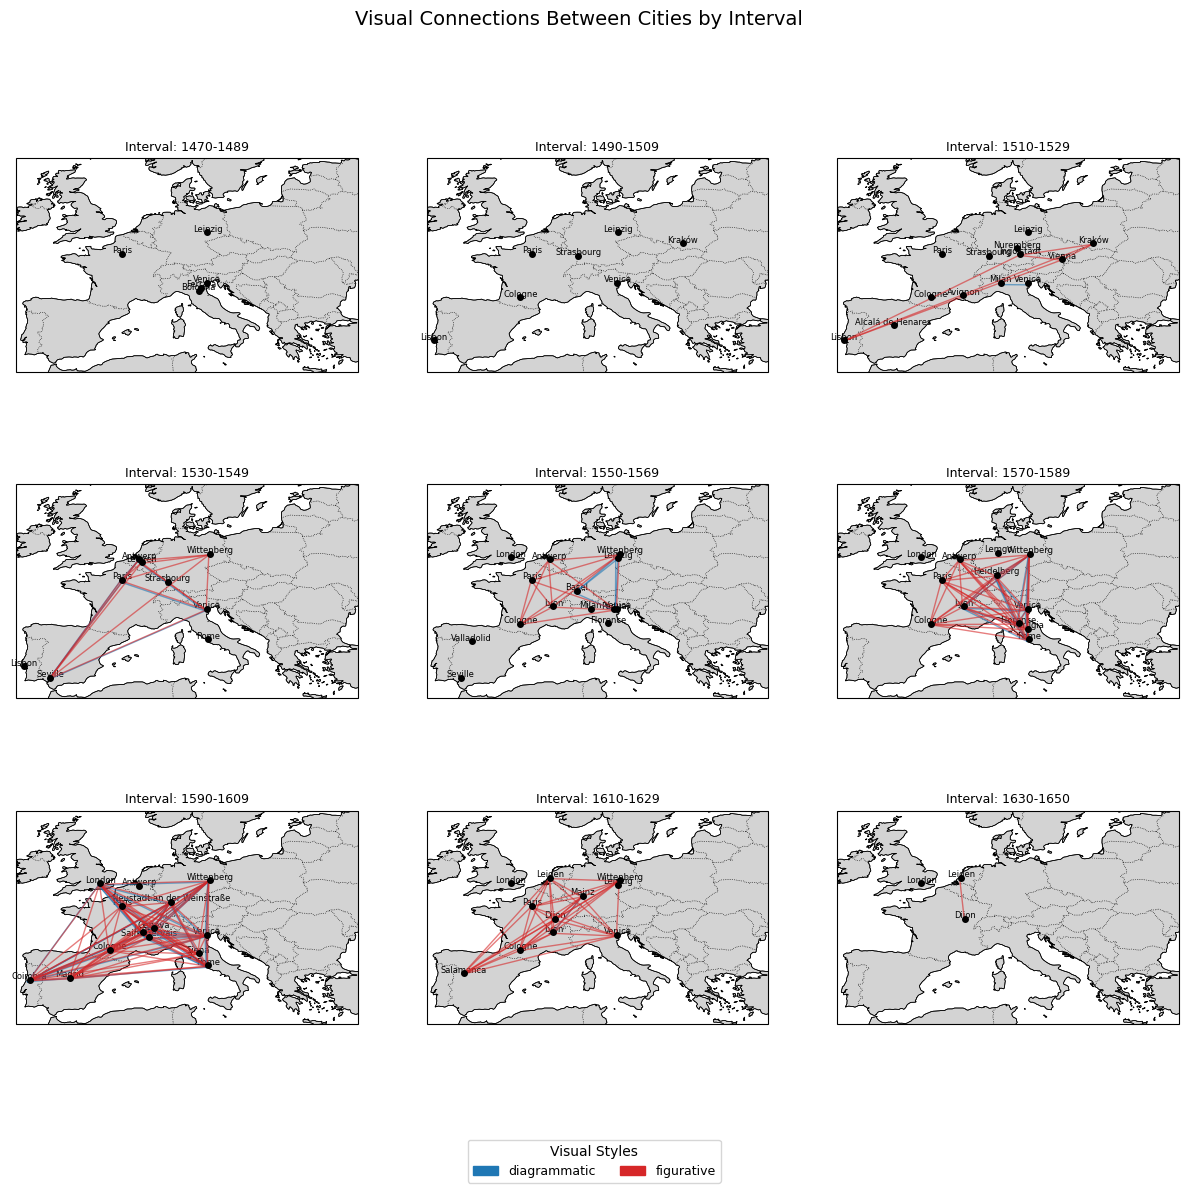

In [74]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.patches as mpatches
from itertools import combinations

# === Visual Tag Groups Only ===
visual_group_map = {
    'diagrammatic': ['diagram', 'simple'],
    'figurative': [
        '3D',
        'human figures',
        'material object figurative element',
        'armilary sphere handle',
        'eye'
    ]
}

visual_tags = list(visual_group_map.keys())

# === Color Map (choose strong, clear colors) ===
tag_color_map = {
    'diagrammatic': '#1f77b4',  # blue
    'figurative': '#d62728',    # red
}

# === Bounding box ===
min_lon, max_lon = -10, 30
min_lat, max_lat = 35, 60

# === Plot function for one interval ===
def plot_tag_lines_on_ax(ax, interval):
    df_interval = visual_df[visual_df['year_interval'] == interval].copy()

    gdf = gpd.GeoDataFrame(
        df_interval,
        geometry=gpd.points_from_xy(df_interval['longitude'], df_interval['latitude']),
        crs="EPSG:4326"
    ).dropna(subset=['longitude', 'latitude'])

    # All cities, even untagged ones
    all_cities_df = df[df['year_interval'] == interval].copy()
    all_cities_df = all_cities_df.dropna(subset=['longitude', 'latitude'])
    all_cities_df = all_cities_df.drop_duplicates(subset=['place'])

    ax.set_extent([min_lon, max_lon, min_lat, max_lat], crs=ccrs.PlateCarree())
    ax.add_feature(cfeature.BORDERS, linestyle=':', linewidth=0.5)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
    ax.add_feature(cfeature.LAND, edgecolor='black', facecolor='lightgray', linewidth=0.5)

    jitter_amount = 0.12

    # === Visual group lines only ===
    for tag_index, (group_label, original_tags) in enumerate(visual_group_map.items()):
        group_cities = gdf[
            gdf[original_tags].eq('yes').any(axis=1)
        ][['place', 'longitude', 'latitude']].drop_duplicates()

        jitter_offset = (tag_index % 5 - 2) * jitter_amount

        for (i1, row1), (i2, row2) in combinations(group_cities.iterrows(), 2):
            if (row1['longitude'] == row2['longitude']) and (row1['latitude'] == row2['latitude']):
                continue
            ax.plot(
                [row1['longitude'] + jitter_offset, row2['longitude'] + jitter_offset],
                [row1['latitude'] + jitter_offset, row2['latitude'] + jitter_offset],
                color=tag_color_map[group_label],
                linewidth=1,
                alpha=0.6,
                transform=ccrs.PlateCarree(),
                zorder=4
            )

    # === City dots ===
    for _, row in all_cities_df.iterrows():
        ax.plot(
            row['longitude'], row['latitude'],
            marker='o', color='black', markersize=4,
            transform=ccrs.PlateCarree(),
            zorder=5
        )
        ax.text(
            row['longitude'], row['latitude'] + 0.15,
            row['place'], fontsize=6, ha='center',
            transform=ccrs.PlateCarree()
        )

    ax.set_title(f"Interval: {interval}", fontsize=9)


# === Plotting in 3×3 grid ===
sorted_intervals = sorted(visual_df['year_interval'].dropna().unique())
per_page = 9
num_pages = int(np.ceil(len(sorted_intervals) / per_page))

for page in range(num_pages):
    start = page * per_page
    end = min((page + 1) * per_page, len(sorted_intervals))
    intervals_subset = sorted_intervals[start:end]

    fig, axs = plt.subplots(
        3, 3,
        figsize=(15, 12),
        subplot_kw={'projection': ccrs.PlateCarree()}
    )
    axs = axs.flatten()

    for i, interval in enumerate(intervals_subset):
        plot_tag_lines_on_ax(axs[i], interval)

    for j in range(len(intervals_subset), 9):
        axs[j].set_visible(False)

    # === Legend ===
    legend_handles = [
        mpatches.Patch(color=color, label=tag) for tag, color in tag_color_map.items()
    ]
    fig.legend(
        handles=legend_handles,
        loc='lower center',
        ncol=2,
        fontsize=9,
        title='Visual Styles'
    )


    
    # Title and layout
    plt.suptitle("Visual Connections Between Cities by Interval", fontsize=14)
    plt.tight_layout(rect=[0, 0.07, 1, 0.95])

    # plt.savefig('/Users/nogashlomi/projects/nog_thesis/figures/plots/source_analysis/1.9_geotemporal.png', dpi=300)

    plt.show()

